# 01: Dataset Audit

## Objective

Before model development, verify the provenance, structure, outcome coding, and predictor definitions of the Wisconsin Diagnostic Breast Cancer (WDBC) dataset.

This stage is intentionally performed before model fitting or outcome-driven exploration.

The objectives are to establish:
1. the exact analysis dataset;
2. the observational unit;
3. the meaning and structure of the predictors;
4. the positive-outcome convention;
5. the absence or presence of missing values and exact duplicate predictor rows;
6. reproducible structural checks that future runs of the analysis must satisfy.

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import sklearn

data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y_original = data.target.copy()
y = (y_original == 0).astype(int)
y.name = "malignant"

## Dataset representation

The analysis uses the WDBC dataset distributed through `sklearn.datasets.load_breast_cancer`.

The dataset contains:
- 569 observations;
- 30 quantitative predictors derived from nuclear morphology;
- 212 malignant observations;
- 357 benign observations.

The scikit-learn representation encodes:
- `0 = malignant`
- `1 = benign`

For this project, the outcome is explicitly recoded as:
- `1 = malignant`
- `0 = benign`

This convention ensures that predicted probabilities consistently refer to the probability of malignancy.

All subsequent model evaluation will use this explicitly recoded outcome rather than relying on the original class ordering.

## Structural audit

The initial structural audit confirmed:
- predictor matrix shape: `569 × 30`;
- all predictors are numeric (`float64`);
- no missing predictor values;
- no missing outcome values;
- no exact duplicate rows across the 30 predictors;
- all expected malignant and benign observations are present;
- no predictor is constant.

The absence of exact duplicate predictor rows does not establish statistical independence of the observations. It only confirms that no two rows contain identical values across all 30 predictors.

In [2]:
feature_audit = pd.DataFrame({
    "feature": X.columns,
    "dtype": X.dtypes.astype(str).values,
    "missing": X.isna().sum().values,
    "n_unique": X.nunique().values,
    "min": X.min().values,
    "max": X.max().values,
})
feature_audit

,feature,dtype,missing,n_unique,min,max
0,mean radius,float64,0,456,6.981000,28.11000
1,mean texture,float64,0,479,9.710000,39.28000
2,mean perimeter,float64,0,522,43.790000,188.50000
3,mean area,float64,0,539,143.500000,2501.00000
4,mean smoothness,float64,0,474,0.052630,0.16340
5,mean compactness,float64,0,537,0.019380,0.34540
6,mean concavity,float64,0,537,0.000000,0.42680
7,mean concave points,float64,0,542,0.000000,0.20120
8,mean symmetry,float64,0,432,0.106000,0.30400
9,mean fractal dimension,float64,0,499,0.049960,0.09744


## Predictor provenance and structure

The 30 predictors are constructed from ten underlying nuclear-morphology characteristics (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension).

Each characteristic is represented using three summaries: `mean`, `standard error`, and `worst`.

$$
10 \text{ morphological characteristics} \times 3 \text{ summaries} = 30 \text{ predictors}.
$$

### Structural validation result

All 30 predictor names matched the expected WDBC feature structure.

## Implications for the analysis

The WDBC predictors contain known structural relationships. Predictor dependence is expected from the feature-construction process itself.

All 30 predictors will remain part of the prespecified analysis dataset.

##
Decisions frozen after Stage 1A–1B

- use the scikit-learn representation of WDBC;
- retain all 569 observations;
- retain all 30 quantitative predictors;
- explicitly encode malignant as `1`;
- perform no imputation or feature selection during dataset preparation.

## Analyses deliberately not performed at this stage

No model fitting, train/test splitting, feature selection, PCA, or hyperparameter optimization was performed during the dataset audit.

## Observation identifiers

The scikit-learn representation used in this project does not expose the
original UCI case identifier as an analysis variable.

Stable internal identifiers (`WDBC_000` to `WDBC_568`) were therefore created
solely for tracking observations across resampling repetitions and generated
result tables.

These identifiers are analytical row identifiers and must not be interpreted
as original patient identifiers.

In [3]:
# 1. Crear IDs estables internos
observation_id = pd.Series(
    [f"WDBC_{i:03d}" for i in range(len(X))],
    name="observation_id"
)

print(observation_id.head())

0    WDBC_000
1    WDBC_001
2    WDBC_002
3    WDBC_003
4    WDBC_004
Name: observation_id, dtype: str


In [4]:
# 2. Construir la tabla máster de análisis
analysis_df = X.copy()

analysis_df.insert(0, "observation_id", observation_id.values)
analysis_df["malignant"] = y.values

print("Analysis table shape:", analysis_df.shape)
print("Unique observation IDs:", analysis_df["observation_id"].nunique())
print("Number malignant:", analysis_df["malignant"].sum())

Analysis table shape: (569, 32)
Unique observation IDs: 569
Number malignant: 212


In [5]:
# 3. Nombres de columnas congelados
FEATURE_COLUMNS = tuple(X.columns)
TARGET_COLUMN = "malignant"
ID_COLUMN = "observation_id"

print("Number of feature columns:", len(FEATURE_COLUMNS))
print("Target:", TARGET_COLUMN)
print("ID:", ID_COLUMN)

# Separación segura
X_analysis = analysis_df.loc[:, FEATURE_COLUMNS].copy()
y_analysis = analysis_df[TARGET_COLUMN].copy()
ids_analysis = analysis_df[ID_COLUMN].copy()

Number of feature columns: 30
Target: malignant
ID: observation_id


## Analysis data contract

All subsequent analyses must operate on the same frozen representation:

- observational unit: one WDBC breast-mass case;
- number of observations: 569;
- predictors: the 30 predefined quantitative WDBC morphology variables;
- predictor order: preserved exactly as distributed by scikit-learn;
- outcome: binary diagnosis recoded as `malignant = 1`, `benign = 0`;
- observation identifier: project-specific internal ID, excluded from modeling;
- missing-value handling: none required;
- feature selection during data preparation: none.

The model input is therefore:

$$X \in \mathbb{R}^{569 \times 30}$$

and:

$$y \in \{0,1\}^{569},$$

where `1` denotes malignancy.

Observation identifiers and the outcome column are never included in the predictor matrix.

In [6]:
# 5. Comprobaciones automáticas de integridad
assert analysis_df.shape == (569, 32)

assert analysis_df[ID_COLUMN].is_unique
assert analysis_df[ID_COLUMN].notna().all()

assert len(FEATURE_COLUMNS) == 30
assert len(set(FEATURE_COLUMNS)) == 30

assert list(X_analysis.columns) == list(FEATURE_COLUMNS)
assert X_analysis.shape == (569, 30)

assert X_analysis.isna().sum().sum() == 0

assert set(y_analysis.unique()) == {0, 1}
assert y_analysis.sum() == 212
assert (y_analysis == 0).sum() == 357

assert ID_COLUMN not in FEATURE_COLUMNS
assert TARGET_COLUMN not in FEATURE_COLUMNS

assert X_analysis.index.equals(y_analysis.index)
assert X_analysis.index.equals(ids_analysis.index)

print("Analysis data contract checks passed.")

Analysis data contract checks passed.


In [7]:
import hashlib
import numpy as np

def compute_dataset_fingerprint(X, y, feature_names):
    hasher = hashlib.sha256()

    # Nombres de variables
    schema = "\n".join(feature_names).encode("utf-8")
    hasher.update(schema)

    # Valores numéricos en bytes (float64 little-endian)
    X_bytes = np.asarray(X, dtype="<f8", order="C").tobytes(order="C")
    hasher.update(X_bytes)

    # Variable objetivo en bytes
    y_bytes = np.asarray(y, dtype=np.uint8).tobytes(order="C")
    hasher.update(y_bytes)

    return hasher.hexdigest()

dataset_sha256 = compute_dataset_fingerprint(
    X_analysis,
    y_analysis,
    FEATURE_COLUMNS
)

print("Analysis dataset SHA-256:")
print(dataset_sha256)

Analysis dataset SHA-256:
be06e11b816f830afa615fe2296762d77eb9e29429b057484484931e7b06ff61


In [8]:
import sys
import sklearn

software_provenance = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
}

dataset_provenance = {
    "dataset": "Wisconsin Diagnostic Breast Cancer (WDBC)",
    "analysis_source": "sklearn.datasets.load_breast_cancer",
    "n_observations": len(X_analysis),
    "n_predictors": len(FEATURE_COLUMNS),
    "n_malignant": int(y_analysis.sum()),
    "n_benign": int((y_analysis == 0).sum()),
    "positive_outcome": "malignant",
    "analysis_sha256": dataset_sha256,
}

print("Software provenance:", software_provenance)
print("\nDataset provenance:", dataset_provenance)

Software provenance: {'python': '3.13.12', 'numpy': '2.4.4', 'pandas': '3.0.2', 'scikit_learn': '1.8.0'}

Dataset provenance: {'dataset': 'Wisconsin Diagnostic Breast Cancer (WDBC)', 'analysis_source': 'sklearn.datasets.load_breast_cancer', 'n_observations': 569, 'n_predictors': 30, 'n_malignant': 212, 'n_benign': 357, 'positive_outcome': 'malignant', 'analysis_sha256': 'be06e11b816f830afa615fe2296762d77eb9e29429b057484484931e7b06ff61'}


In [9]:
# Validar orden estricto de identificadores
assert ids_analysis.iloc[0] == "WDBC_000"
assert ids_analysis.iloc[-1] == "WDBC_568"
assert ids_analysis.tolist() == [f"WDBC_{i:03d}" for i in range(569)]

print("Observation ordering is stable.\n")

# Resumen final de integridad
data_contract_summary = pd.Series({
    "n_observations": len(analysis_df),
    "n_predictors": len(FEATURE_COLUMNS),
    "n_malignant": int(y_analysis.sum()),
    "n_benign": int((y_analysis == 0).sum()),
    "missing_predictor_values": int(X_analysis.isna().sum().sum()),
    "duplicate_predictor_rows": int(X_analysis.duplicated().sum()),
    "unique_observation_ids": int(ids_analysis.nunique()),
    "dataset_sha256": dataset_sha256,
})

print(data_contract_summary)

Observation ordering is stable.

n_observations                                                            569
n_predictors                                                               30
n_malignant                                                               212
n_benign                                                                  357
missing_predictor_values                                                    0
duplicate_predictor_rows                                                    0
unique_observation_ids                                                    569
dataset_sha256              be06e11b816f830afa615fe2296762d77eb9e29429b057...
dtype: object


## Frozen data contract

Following the dataset audit, the analysis dataset is frozen before any model fitting.

The study will use:
- exactly 569 WDBC observations;
- exactly the 30 predefined quantitative morphology predictors;
- their original scikit-learn ordering;
- an explicitly recoded binary outcome where malignancy equals 1;
- stable project-specific observation IDs for tracking predictions.

No observations or predictors will be removed on the basis of subsequent model performance.

The dataset fingerprint and software versions have been recorded to detect unintended changes to the analysis input.

Any future modification of this data contract must be treated as a protocol change and documented explicitly rather than silently incorporated into the analysis.


# Stage 2: Resampling design

## Objective

The primary analysis uses repeated stratified 5-fold cross-validation.

Before generating all repetitions or fitting any model, the resampling procedure is audited independently.

Within each repetition:
- the 569 observations are divided into five non-overlapping test folds;
- each observation appears in exactly one test fold;
- the remaining four folds form the corresponding training set;
- no observation can be simultaneously present in train and test;
- class proportions are approximately preserved by stratification;
- exactly the same partitions will later be used for all modeling procedures.

In [10]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np

# Configuración de auditoría
N_SPLITS = 5
AUDIT_SEED = 20260923

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=AUDIT_SEED)
single_repeat_splits = list(cv.split(X_analysis, y_analysis))

# 1. Resumen por fold
fold_summary = []
for fold, (train_idx, test_idx) in enumerate(single_repeat_splits):
    y_train = y_analysis.iloc[train_idx]
    y_test = y_analysis.iloc[test_idx]
    
    fold_summary.append({
        "fold": fold,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "train_malignant": int(y_train.sum()),
        "train_benign": int((y_train == 0).sum()),
        "test_malignant": int(y_test.sum()),
        "test_benign": int((y_test == 0).sum()),
        "train_malignant_prop": y_train.mean(),
        "test_malignant_prop": y_test.mean(),
    })

fold_summary_df = pd.DataFrame(fold_summary)
print("--- RESUMEN DE FOLDS (1 REP) ---")
print(fold_summary_df)

# 2. Auditoría de solapamiento
for fold, (train_idx, test_idx) in enumerate(single_repeat_splits):
    overlap = set(train_idx).intersection(test_idx)
    assert len(overlap) == 0, f"Solapamiento detectado en el fold {fold}"

print("\n✓ No train/test overlap detected.")

# 3. Apariciones en Test y Train
test_counts = np.zeros(len(X_analysis), dtype=int)
train_counts = np.zeros(len(X_analysis), dtype=int)

for train_idx, test_idx in single_repeat_splits:
    test_counts[test_idx] += 1
    train_counts[train_idx] += 1

assert np.all(test_counts == 1), "Error en conteo de test"
assert np.all(train_counts == N_SPLITS - 1), "Error en conteo de train"

print("✓ Every observation appears exactly once in test.")
print("✓ Every observation appears in training exactly four times.")

# 4. Auditoría de balances y tamaños
assert (fold_summary_df["n_test"].max() - fold_summary_df["n_test"].min() <= 1)
assert (fold_summary_df["test_malignant"].max() - fold_summary_df["test_malignant"].min() <= 1)
assert (fold_summary_df["test_benign"].max() - fold_summary_df["test_benign"].min() <= 1)

print("✓ Fold sizes and class counts are appropriately balanced.")

# 5. Tabla de asignación de folds
fold_assignment = pd.DataFrame({
    "observation_id": ids_analysis.values,
    "malignant": y_analysis.values,
    "test_fold": -1
})

for fold, (train_idx, test_idx) in enumerate(single_repeat_splits):
    fold_assignment.loc[test_idx, "test_fold"] = fold

assert (fold_assignment["test_fold"] >= 0).all()
assert fold_assignment["observation_id"].is_unique
print("✓ Fold assignment table is complete.")

--- RESUMEN DE FOLDS (1 REP) ---
   fold  n_train  n_test  train_malignant  train_benign  test_malignant  \
0     0      455     114              169           286              43   
1     1      455     114              169           286              43   
2     2      455     114              170           285              42   
3     3      455     114              170           285              42   
4     4      456     113              170           286              42   

   test_benign  train_malignant_prop  test_malignant_prop  
0           71              0.371429             0.377193  
1           71              0.371429             0.377193  
2           72              0.373626             0.368421  
3           72              0.373626             0.368421  
4           71              0.372807             0.371681  

✓ No train/test overlap detected.
✓ Every observation appears exactly once in test.
✓ Every observation appears in training exactly four times.
✓ Fold size

## Interpretation of one CV repetition

One 5-fold CV repetition generates five related model fits.

For each observation, only the model for which that observation belongs to the held-out fold is used to obtain its out-of-sample prediction.

After all five folds have been evaluated, the repetition produces a complete vector of 569 out-of-sample predictions:

$$\hat{\mathbf p}^{(r)} = (p_{1r}, p_{2r}, \dots, p_{569r}).$$

The five fitted models are not treated as independent experiments.

The purpose of the fold structure is to provide out-of-sample predictions for every observation while using approximately 80% of the observed dataset for each development fit.

In [11]:
from numpy.random import SeedSequence

N_REPEATS = 50
MASTER_RESAMPLING_SEED = 20260923

# Generación de semillas reproducibles
seed_sequence = SeedSequence(MASTER_RESAMPLING_SEED)
repeat_seeds = [
    int(child.generate_state(1)[0])
    for child in seed_sequence.spawn(N_REPEATS)
]

assert len(repeat_seeds) == 50
assert len(set(repeat_seeds)) == 50
print("✓ Generated 50 unique reproducible resampling seeds.")

# Construcción del Manifiesto Completo de Remuestreo
resampling_manifest = []

for repeat, seed in enumerate(repeat_seeds):
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(X_analysis, y_analysis)):
        for idx in test_idx:
            resampling_manifest.append({
                "repeat": repeat,
                "seed": seed,
                "fold": fold,
                "observation_id": ids_analysis.iloc[idx],
                "row_index": idx,
                "malignant": int(y_analysis.iloc[idx]),
            })

resampling_manifest = pd.DataFrame(resampling_manifest)

# Verificaciones críticas del Manifiesto
assert len(resampling_manifest) == 569 * N_REPEATS, "Número inesperado de filas"

counts_per_case = resampling_manifest.groupby("observation_id").size()
assert (counts_per_case == N_REPEATS).all(), "Falta o sobra alguna observación"

counts_per_repeat = resampling_manifest.groupby("repeat").size()
assert (counts_per_repeat == 569).all(), "Falta o sobra alguna repetición"

duplicates = resampling_manifest.duplicated(["repeat", "observation_id"]).sum()
assert duplicates == 0, "Existen duplicados en repeat/observation"

print(f"\n✓ Resampling manifest generated successfully! Shape: {resampling_manifest.shape}")
print("✓ Every observation has exactly one OOS assignment in every repetition.")
print("✓ Duplicate repeat-observation assignments: 0")

✓ Generated 50 unique reproducible resampling seeds.

✓ Resampling manifest generated successfully! Shape: (28450, 6)
✓ Every observation has exactly one OOS assignment in every repetition.
✓ Duplicate repeat-observation assignments: 0


## Frozen resampling contract

The primary resampling procedure was defined before fitting any predictive model.

Parameters:

- 5-fold stratified cross-validation
- shuffling enabled
- 50 initial repetitions
- one reproducible seed per repetition derived from a master resampling seed
- identical fold assignments for all modeling procedures
- exactly one out-of-sample assignment per observation and repetition
- 569 out-of-sample observations per repetition
- 28,450 total observation-repetition assignments

The repetitions are repeated realizations of the same prespecified
redevelopment procedure conditional on the observed WDBC dataset.

They are not treated as independent patient cohorts.

In [12]:
resampling_contract = {
    "n_splits": N_SPLITS,
    "n_repeats": N_REPEATS,
    "stratified": True,
    "shuffle": True,
    "master_seed": MASTER_RESAMPLING_SEED,
    "same_splits_for_all_models": True,
}

resampling_contract

{'n_splits': 5,
 'n_repeats': 50,
 'stratified': True,
 'shuffle': True,
 'master_seed': 20260923,
 'same_splits_for_all_models': True}

In [13]:
from pathlib import Path

split_dir = Path("artifacts/splits")
split_dir.mkdir(parents=True, exist_ok=True)

manifest_path = split_dir / "resampling_manifest.csv"

resampling_manifest.to_csv(
    manifest_path,
    index=False
)

print("Saved:", manifest_path)

Saved: artifacts/splits/resampling_manifest.csv


In [14]:
import hashlib

with open(manifest_path, "rb") as f:
    manifest_sha256 = hashlib.sha256(f.read()).hexdigest()

print("Resampling manifest SHA-256:")
print(manifest_sha256)

Resampling manifest SHA-256:
d2bd8ab9e86c1d05dd4291954f873f13553068bcf02271f7fb873bd35089d499


# Stage 3 - Prevalence-only baseline

Testing the complete data-to-prediction pipeline using a naive null model:

$$\hat{p} = \frac{\# \text{malignant}_{\text{train}}}{n_{\text{train}}}$$

This model completely ignores predictor variables ($X$) and serves as a baseline check for infrastructure, calibration, and discrimination.

In [15]:
import numpy as np
import pandas as pd

prevalence_predictions = []

for repeat in range(N_REPEATS):
    repeat_manifest = resampling_manifest[resampling_manifest["repeat"] == repeat]

    for fold in range(N_SPLITS):
        fold_test = repeat_manifest[repeat_manifest["fold"] == fold]
        test_idx = fold_test["row_index"].to_numpy()

        # Obtener entrenamiento de forma segura excluyendo índices de test
        train_mask = np.ones(len(y_analysis), dtype=bool)
        train_mask[test_idx] = False
        train_idx = np.where(train_mask)[0]

        # Prevalencia calculada STRICTLY en entrenamiento
        y_train = y_analysis.iloc[train_idx]
        train_prevalence = y_train.mean()

        for idx in test_idx:
            prevalence_predictions.append({
                "model": "prevalence",
                "repeat": repeat,
                "fold": fold,
                "observation_id": ids_analysis.iloc[idx],
                "row_index": int(idx),
                "y_true": int(y_analysis.iloc[idx]),
                "predicted_probability": float(train_prevalence),
                "n_train": len(train_idx),
                "train_prevalence": float(train_prevalence),
            })

prevalence_predictions = pd.DataFrame(prevalence_predictions)
print("Prevalence predictions shape:", prevalence_predictions.shape)
prevalence_predictions.head()

Prevalence predictions shape: (28450, 9)


,model,repeat,fold,observation_id,row_index,y_true,predicted_probability,n_train,train_prevalence
0,prevalence,0,0,WDBC_004,4,1,0.371429,455,0.371429
1,prevalence,0,0,WDBC_006,6,1,0.371429,455,0.371429
2,prevalence,0,0,WDBC_007,7,1,0.371429,455,0.371429
3,prevalence,0,0,WDBC_010,10,1,0.371429,455,0.371429
4,prevalence,0,0,WDBC_021,21,0,0.371429,455,0.371429


In [16]:
# 1. Comprobaciones de estructura y dimensiones
assert len(prevalence_predictions) == 569 * N_REPEATS
assert prevalence_predictions[["repeat", "observation_id"]].duplicated().sum() == 0
assert prevalence_predictions["predicted_probability"].notna().all()
assert prevalence_predictions["predicted_probability"].between(0, 1).all()
assert prevalence_predictions.groupby("repeat").size().eq(569).all()
assert prevalence_predictions.groupby("observation_id").size().eq(N_REPEATS).all()

print("✓ Prevalence baseline OOS prediction checks passed.")

# 2. Comprobación de fuga de datos (1 única prevalencia por fold)
predictions_per_fold = (
    prevalence_predictions
    .groupby(["repeat", "fold"])["predicted_probability"]
    .nunique()
)

assert (predictions_per_fold == 1).all()
print("✓ Each fold uses exactly one training-derived prevalence.")

✓ Prevalence baseline OOS prediction checks passed.
✓ Each fold uses exactly one training-derived prevalence.


In [17]:
from sklearn.metrics import brier_score_loss, roc_auc_score

# 1. Métricas Brier por repetición
baseline_brier = (
    prevalence_predictions
    .groupby("repeat")
    .apply(lambda df: brier_score_loss(df["y_true"], df["predicted_probability"]))
    .rename("brier")
    .reset_index()
)

print("--- BRIER SCORE SUMMARY ---")
print(baseline_brier["brier"].describe())

# 2. Comprobación de AUC por Fold (Debe ser exactamente 0.5)
baseline_fold_auc = []
for (repeat, fold), df in prevalence_predictions.groupby(["repeat", "fold"]):
    auc = roc_auc_score(df["y_true"], df["predicted_probability"])
    baseline_fold_auc.append({
        "repeat": repeat,
        "fold": fold,
        "auc": auc,
        "n_positive": int(df["y_true"].sum()),
        "n_negative": int((df["y_true"] == 0).sum()),
    })

baseline_fold_auc = pd.DataFrame(baseline_fold_auc)

# Verificación formal: 250 folds deben tener AUC = 0.5
auc_counts = baseline_fold_auc["auc"].value_counts()
print("\n--- FOLD AUC VALUE COUNTS ---")
print(auc_counts)

assert (baseline_fold_auc["auc"] == 0.5).all()

# 3. AUC ponderado por repetición
def weighted_fold_auc(df):
    weights = df["n_positive"] * df["n_negative"]
    return np.average(df["auc"], weights=weights)

baseline_auc = (
    baseline_fold_auc
    .groupby("repeat")
    .apply(weighted_fold_auc)
    .rename("auc")
    .reset_index()
)

assert (baseline_auc["auc"] == 0.5).all()
print("\n✓ All 250 fold AUCs = 0.5")
print("✓ All 50 repetition AUCs = 0.5")

--- BRIER SCORE SUMMARY ---
count    5.000000e+01
mean     2.337738e-01
std      2.803737e-17
min      2.337738e-01
25%      2.337738e-01
50%      2.337738e-01
75%      2.337738e-01
max      2.337738e-01
Name: brier, dtype: float64

--- FOLD AUC VALUE COUNTS ---
auc
0.5    250
Name: count, dtype: int64

✓ All 250 fold AUCs = 0.5
✓ All 50 repetition AUCs = 0.5


In [18]:
baseline_individual = (
    prevalence_predictions
    .groupby("observation_id")["predicted_probability"]
    .agg(
        median_probability="median",
        p10=lambda x: x.quantile(0.10),
        p90=lambda x: x.quantile(0.90),
        prediction_variance="var",
    )
)

baseline_individual["resampling_width"] = (
    baseline_individual["p90"] - baseline_individual["p10"]
)

print("--- INDIVIDUAL RESAMPLING WIDTH (W_i) SUMMARY ---")
print(baseline_individual["resampling_width"].describe())

--- INDIVIDUAL RESAMPLING WIDTH (W_i) SUMMARY ---
count    569.000000
mean       0.002198
std        0.000000
min        0.002198
25%        0.002198
50%        0.002198
75%        0.002198
max        0.002198
Name: resampling_width, dtype: float64


Verification one more time...


In [19]:
(
    prevalence_predictions
    .groupby("observation_id")["predicted_probability"]
    .nunique()
    .value_counts()
)

predicted_probability
3    569
Name: count, dtype: int64

In [20]:
np.sort(
    prevalence_predictions["predicted_probability"].unique()
)

array([0.37142857, 0.37280702, 0.37362637])

## Prevalence-only baseline: interpretation

The prevalence-only control behaved as expected.

Across all 250 held-out folds, ROC-AUC was exactly 0.5 because every
observation within a fold receives the same training-derived probability.

The repetition-level Brier score was effectively identical across all
50 repetitions. This occurs because stratified five-fold cross-validation
preserves nearly identical class counts across folds; the prevalence-only
model depends exclusively on those counts rather than on observation identity.

Individual prediction resampling widths were also identical across all
569 observations ($W_i \approx 0.00220$). This reflects the narrow range of
training-set malignancy prevalences permitted by the stratified fold
structure.

This control demonstrates that prediction stability and predictive utility
are distinct properties: a prediction procedure can be highly stable while
having no discriminatory ability.

# Stage 4: Logistic Regression

## Prespecified learning procedure

The first predictive model is a fixed L2-regularized logistic regression.

Predictors are standardized using statistics estimated exclusively from the
corresponding training fold.

The prespecified procedure is:

- `StandardScaler`
- L2-regularized logistic regression
- `C = 1.0`
- `solver = "lbfgs"`
- `max_iter = 5000`
- no class weighting
- no feature selection
- no hyperparameter tuning

Under scikit-learn >= 1.8, the default `l1_ratio = 0.0`
corresponds to pure L2 regularization. The deprecated `penalty`
argument is therefore not explicitly specified.

All preprocessing and fitting occur strictly within the training portion of
each fold.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# 1. Pipeline estricto sin argumentos deprecados ni parámetros inoperantes
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=5000
    ))
])

# 2. Extracción del primer split auditado (Repetición 0, Fold 0)
train_idx, test_idx = single_repeat_splits[0]

X_train = X_analysis.iloc[train_idx]
X_test = X_analysis.iloc[test_idx]

y_train = y_analysis.iloc[train_idx]
y_test = y_analysis.iloc[test_idx]

# 3. Ajuste exclusivo en entrenamiento
lr_pipeline.fit(X_train, y_train)

# 4. Auditoría de dimensiones y convergencia
print("Train size:", len(train_idx))
print("Test size:", len(test_idx))
print("Model classes:", lr_pipeline.named_steps["model"].classes_)
print("Number of optimizer iterations:", lr_pipeline.named_steps["model"].n_iter_[0])

# Verificación del índice correspondiente a la clase positiva (1 = maligno)
classes_list = list(lr_pipeline.named_steps["model"].classes_)
assert classes_list == [0, 1], "Mapeo inesperado de clases en el estimador"

malignant_class_index = classes_list.index(1)

# Extracción de probabilidades comprobadas
p_test = lr_pipeline.predict_proba(X_test)[:, malignant_class_index]

Train size: 455
Test size: 114
Model classes: [0 1]
Number of optimizer iterations: 16


In [23]:
# 1. Auditoría del transformador StandardScaler
scaler = lr_pipeline.named_steps["scaler"]

# Verificación numérica: las medias aprendidas coinciden con X_train
np.testing.assert_allclose(
    scaler.mean_,
    X_train.mean(axis=0).to_numpy(),
    err_msg="Error: El scaler utilizó estadísticas fuera del conjunto de entrenamiento"
)

print("✓ Scaler statistics were learned exclusively from the training fold.")

# 2. Contrato de integridad del vector de probabilidades
assert len(p_test) == len(test_idx), "Dimensión incoherente entre predicciones y test fold"
assert np.isfinite(p_test).all(), "Existen valores inf o nan en las probabilidades"
assert ((p_test >= 0.0) & (p_test <= 1.0)).all(), "Probabilidades fuera del rango axiomático [0, 1]"

print("✓ First-fold malignant probabilities are valid.")

# 3. Resumen estadístico del primer test fold
print("\nFirst fold probability distribution summary:")
print(pd.Series(p_test).describe())

✓ Scaler statistics were learned exclusively from the training fold.
✓ First-fold malignant probabilities are valid.

First fold probability distribution summary:
count    1.140000e+02
mean     3.765026e-01
std      4.596127e-01
min      8.670889e-07
25%      6.079467e-04
50%      2.164111e-02
75%      9.975474e-01
max      1.000000e+00
dtype: float64


## Stage 4D: Generate all 28,450 LR OOS predictions

We generate out-of-sample (OOS) predictions across all 50 repetitions (250 fold fits) using the pre-congealed `resampling_manifest`.

To prevent state leakage across folds, we define a factory function `make_lr_pipeline()` that produces a fresh instance of the pre-specified `StandardScaler` + `LogisticRegression` pipeline for every fit.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

def make_lr_pipeline():
    """Garantiza la creación de un Pipeline fresco en cada fold para evitar la acumulación de estado."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1.0,
            solver="lbfgs",
            max_iter=5000
        ))
    ])

lr_predictions = []
lr_fit_diagnostics = []

for repeat in range(N_REPEATS):

    repeat_manifest = resampling_manifest[
        resampling_manifest["repeat"] == repeat
    ]

    for fold in range(N_SPLITS):

        fold_test = repeat_manifest[
            repeat_manifest["fold"] == fold
        ]

        test_idx = fold_test["row_index"].to_numpy(dtype=int)

        train_mask = np.ones(len(X_analysis), dtype=bool)
        train_mask[test_idx] = False

        train_idx = np.where(train_mask)[0]

        # Explicit no-overlap check
        assert len(np.intersect1d(train_idx, test_idx)) == 0

        X_train = X_analysis.iloc[train_idx]
        X_test = X_analysis.iloc[test_idx]
        y_train = y_analysis.iloc[train_idx]

        model = make_lr_pipeline()
        model.fit(X_train, y_train)

        # Verify positive class explicitly
        classes = model.named_steps["model"].classes_
        assert np.array_equal(classes, np.array([0, 1]))

        malignant_idx = np.flatnonzero(classes == 1).item()

        p_test = model.predict_proba(X_test)[:, malignant_idx]

        # Basic prediction checks
        assert len(p_test) == len(test_idx)
        assert np.isfinite(p_test).all()
        assert ((p_test >= 0) & (p_test <= 1)).all()

        # Training-only scaler check
        np.testing.assert_allclose(
            model.named_steps["scaler"].mean_,
            X_train.mean(axis=0).to_numpy()
        )

        n_iter = int(model.named_steps["model"].n_iter_[0])

        lr_fit_diagnostics.append({
            "repeat": repeat,
            "fold": fold,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "n_iter": n_iter,
        })

        for idx, prob in zip(test_idx, p_test):
            lr_predictions.append({
                "model": "logistic_regression",
                "repeat": repeat,
                "fold": fold,
                "observation_id": ids_analysis.iloc[idx],
                "row_index": int(idx),
                "y_true": int(y_analysis.iloc[idx]),
                "predicted_probability": float(prob),
            })

lr_predictions = pd.DataFrame(lr_predictions)
lr_fit_diagnostics = pd.DataFrame(lr_fit_diagnostics)

### Stage 4D.1 to 4D.3: Prediction Table, Convergence, and Manifest Audit

Before evaluating performance metrics, we verify structural invariants:
1. **Dimensions & Completeness:** Exactly 28,450 OOS predictions (569 observations $\times$ 50 repetitions).
2. **Convergence:** Every single L-BFGS optimizer fit converged well below `max_iter=5000`.
3. **Manifest Alignment:** The exact alignment of predictions against the frozen resampling manifest.

In [28]:
# Stage 4D.1 — Audit table shape and invariants
print("Prediction table shape:", lr_predictions.shape)
print("Fit diagnostics shape:", lr_fit_diagnostics.shape)

assert len(lr_predictions) == 569 * N_REPEATS
assert lr_predictions[["repeat", "observation_id"]].duplicated().sum() == 0
assert lr_predictions.groupby("repeat").size().eq(569).all()
assert lr_predictions.groupby("observation_id").size().eq(N_REPEATS).all()
assert lr_predictions["predicted_probability"].notna().all()
assert lr_predictions["predicted_probability"].between(0, 1).all()
assert len(lr_fit_diagnostics) == 250

# Stage 4D.2 — Convergence audit
print("Maximum optimizer iterations used:", lr_fit_diagnostics["n_iter"].max())
assert (lr_fit_diagnostics["n_iter"] < 5000).all()

# Stage 4D.3 — Verify predictions match the frozen manifest
manifest_keys = (
    resampling_manifest[["repeat", "fold", "observation_id", "row_index"]]
    .sort_values(["repeat", "fold", "row_index"])
    .reset_index(drop=True)
)

prediction_keys = (
    lr_predictions[["repeat", "fold", "observation_id", "row_index"]]
    .sort_values(["repeat", "fold", "row_index"])
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(manifest_keys, prediction_keys)

print("✓ All 28,450 LR predictions are genuine OOS predictions corresponding to the frozen manifest.")

Prediction table shape: (28450, 7)
Fit diagnostics shape: (250, 5)
Maximum optimizer iterations used: 22
✓ All 28,450 LR predictions are genuine OOS predictions corresponding to the frozen manifest.


## Stage 4E: Global Performance Metrics

We compute repetition-level Brier scores and ROC-AUC scores using fully vectorized Pandas aggregations:

- **Brier Score:** Evaluated per repetition across all 569 OOS predictions:
  $$\text{Brier}_r = \frac{1}{N} \sum_{i=1}^{N} (y_{ir} - p_{ir})^2$$
- **Repetition ROC-AUC:** Weighted average of fold-level ROC-AUCs using pair weights $w_{rk} = n_{+,rk} \cdot n_{-,rk}$:
  $$\text{AUC}_r = \frac{\sum_k w_{rk} \text{AUC}_{rk}}{\sum_k w_{rk}}$$

In [29]:
from sklearn.metrics import brier_score_loss, roc_auc_score

# 4E.1 — Vectorized Brier score
lr_brier = (
    lr_predictions
    .assign(squared_error=lambda df: (df["y_true"] - df["predicted_probability"]) ** 2)
    .groupby("repeat", as_index=False)
    .agg(brier=("squared_error", "mean"))
)

# Sanity Check punctual con Scikit-Learn (solo repetición 0)
check_df = lr_predictions[lr_predictions["repeat"] == 0]
check_sklearn = brier_score_loss(check_df["y_true"], check_df["predicted_probability"])
check_vec = lr_brier.loc[lr_brier["repeat"] == 0, "brier"].item()
np.testing.assert_allclose(check_sklearn, check_vec)
print("✓ Vectorized Brier matches sklearn.")

# 4E.2 — Fold-specific ROC-AUC
lr_fold_auc = []
for (repeat, fold), df in lr_predictions.groupby(["repeat", "fold"]):
    n_positive = int(df["y_true"].sum())
    n_negative = int((df["y_true"] == 0).sum())
    auc = roc_auc_score(df["y_true"], df["predicted_probability"])

    lr_fold_auc.append({
        "repeat": repeat,
        "fold": fold,
        "auc": auc,
        "n_positive": n_positive,
        "n_negative": n_negative,
        "pair_weight": n_positive * n_negative,
    })

lr_fold_auc = pd.DataFrame(lr_fold_auc)
assert len(lr_fold_auc) == 250
assert lr_fold_auc["auc"].between(0, 1).all()

# 4E.3 — Vectorized weighted repetition AUC
lr_auc = (
    lr_fold_auc
    .assign(weighted_auc=lambda df: df["auc"] * df["pair_weight"])
    .groupby("repeat", as_index=False)
    .agg(
        weighted_auc_sum=("weighted_auc", "sum"),
        total_pair_weight=("pair_weight", "sum"),
    )
)
lr_auc["auc"] = lr_auc["weighted_auc_sum"] / lr_auc["total_pair_weight"]
lr_auc = lr_auc[["repeat", "auc"]]

✓ Vectorized Brier matches sklearn.


## Stage 4F: Individual Prediction Stability

For each observation $i \in \{1, \dots, 569\}$, we extract the 50 OOS predicted probabilities $\{p_{i1}, \dots, p_{i50}\}$ and compute our primary prediction stability estimand:
$$W_i = P_{90}(p_i) - P_{10}(p_i)$$

Quantiles are explicitly calculated using `method="linear"`.

In [30]:
def q10(x):
    return np.quantile(x.to_numpy(), 0.10, method="linear")

def q90(x):
    return np.quantile(x.to_numpy(), 0.90, method="linear")

lr_individual = (
    lr_predictions
    .groupby("observation_id")
    .agg(
        y_true=("y_true", "first"),
        median_probability=("predicted_probability", "median"),
        p10=("predicted_probability", q10),
        p90=("predicted_probability", q90),
        prediction_variance=("predicted_probability", "var"),
        n_oos_predictions=("predicted_probability", "size"),
    )
    .reset_index()
)

lr_individual["resampling_width"] = (
    lr_individual["p90"] - lr_individual["p10"]
)

# Audit Individual Table
assert len(lr_individual) == 569
assert (lr_individual["n_oos_predictions"] == 50).all()
assert (lr_individual["resampling_width"] >= 0).all()
assert lr_individual["median_probability"].between(0, 1).all()
assert lr_individual["p10"].between(0, 1).all()
assert lr_individual["p90"].between(0, 1).all()

print("✓ Individual LR stability table validated.")

✓ Individual LR stability table validated.


## Stage 4G: Visualizing Prediction Stability vs. Median Probability

We plot the median OOS predicted probability $\text{Median}(p_i)$ against the individual resampling width $W_i$. 

This directly explores whether prediction instability is concentrated around boundary/intermediate probabilities or if it extends into extreme predictions.

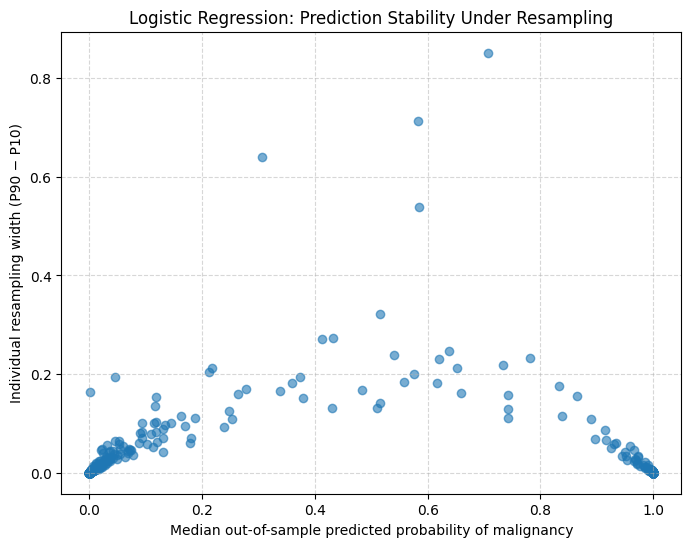


--- 1. OPTIMIZER ITERATIONS SUMMARY ---
count    250.000000
mean      18.360000
std        1.546599
min       14.000000
25%       17.000000
50%       18.000000
75%       20.000000
max       22.000000
Name: n_iter, dtype: float64

--- 2. BRIER SCORE SUMMARY ---
count    50.000000
mean      0.020547
std       0.001677
min       0.017014
25%       0.019437
50%       0.020540
75%       0.021681
max       0.024350
Name: brier, dtype: float64

--- 3. REPETITION-LEVEL AUC SUMMARY ---
count    50.000000
mean      0.994556
std       0.001299
min       0.990156
25%       0.994136
50%       0.994715
75%       0.995375
max       0.996564
Name: auc, dtype: float64

--- 4. INDIVIDUAL RESAMPLING WIDTH (W_i) SUMMARY ---
count    569.000000
mean       0.025813
std        0.074385
min        0.000000
10%        0.000001
25%        0.000073
50%        0.001004
75%        0.012490
90%        0.072620
95%        0.157334
99%        0.271392
max        0.851826
Name: resampling_width, dtype: float64


In [31]:
import matplotlib.pyplot as plt

# 1. Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(
    lr_individual["median_probability"],
    lr_individual["resampling_width"],
    alpha=0.6
)
plt.xlabel("Median out-of-sample predicted probability of malignancy")
plt.ylabel("Individual resampling width (P90 − P10)")
plt.title("Logistic Regression: Prediction Stability Under Resampling")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 2. Impresión de los 4 outputs solicitados para análisis
print("\n--- 1. OPTIMIZER ITERATIONS SUMMARY ---")
print(lr_fit_diagnostics["n_iter"].describe())

print("\n--- 2. BRIER SCORE SUMMARY ---")
print(lr_brier["brier"].describe())

print("\n--- 3. REPETITION-LEVEL AUC SUMMARY ---")
print(lr_auc["auc"].describe())

print("\n--- 4. INDIVIDUAL RESAMPLING WIDTH (W_i) SUMMARY ---")
print(lr_individual["resampling_width"].describe(
    percentiles=[.10, .25, .50, .75, .90, .95, .99]
))

## Stage 4F.1: Inspection of Top Instability Cases

To better understand the right tail of the $W_i$ distribution, we inspect the 10 most sensitive observations and examine the full empirical distribution of $OOS$ predicted probabilities across the 50 repetitions for the 3 most extreme cases.

This allows us to distinguish between a **gradual dispersion** in predictions versus a **bimodal/discontinuous jump** caused by specific training perturbations.

In [32]:
# 1. Tabla con las 10 observaciones con mayor W_i
top10_lr = (
    lr_individual
    .sort_values("resampling_width", ascending=False)
    .head(10)
    [[
        "observation_id",
        "y_true",
        "median_probability",
        "p10",
        "p90",
        "resampling_width",
        "prediction_variance",
    ]]
)

print("--- TOP 10 MOST SENSITIVE OBSERVATIONS (LR) ---")
print(top10_lr.to_string(index=False))

# 2. Inspección de los 50 valores individuales de los Top 3 casos
top3_ids = lr_individual.nlargest(3, "resampling_width")["observation_id"].tolist()

print("\n--- FULL 50 OOS PREDICTED PROBABILITIES FOR TOP 3 CASES ---")
for obs_id in top3_ids:
    values = (
        lr_predictions
        .loc[lr_predictions["observation_id"] == obs_id, "predicted_probability"]
        .sort_values()
        .to_numpy()
    )
    print(f"\nObservation ID: {obs_id}")
    print(np.round(values, 4))

--- TOP 10 MOST SENSITIVE OBSERVATIONS (LR) ---
observation_id  y_true  median_probability      p10      p90  resampling_width  prediction_variance
      WDBC_038       1            0.706837 0.042433 0.894260          0.851826             0.104935
      WDBC_068       0            0.582392 0.176582 0.889993          0.713412             0.069829
      WDBC_190       1            0.305278 0.132610 0.772342          0.639732             0.052532
      WDBC_146       1            0.584808 0.272325 0.810990          0.538665             0.038735
      WDBC_238       0            0.516281 0.370478 0.692961          0.322483             0.014637
      WDBC_157       0            0.432844 0.304906 0.577976          0.273071             0.011815
      WDBC_455       0            0.413379 0.325616 0.596218          0.270602             0.012830
      WDBC_541       0            0.637519 0.519081 0.765913          0.246832             0.009351
      WDBC_013       1            0.539891 0.401128 

## Stage 4H: Monte-Carlo Precision Diagnostic for Primary Stability Summaries

Before concluding Stage 4, we evaluate whether $R = 50$ repetitions are numerically sufficient to produce stable estimates of our primary cohort-level stability summaries:
- $\text{Median}(W_i)$
- $P_{90}(W_i)$

We draw $B = 2,000$ non-parametric Monte-Carlo resamples of the **repetitions** (resampling complete columns of the $569 \times 50$ probability matrix). 

> **Note:** This diagnostic quantifies the *approximation error* introduced by using 50 realizations instead of an infinite number of repetitions; it is **not** a population confidence interval.

In [33]:
# 1. Matriz de probabilidades (569 observaciones x 50 repeticiones)
lr_probability_matrix = (
    lr_predictions
    .pivot(
        index="observation_id",
        columns="repeat",
        values="predicted_probability"
    )
)

assert lr_probability_matrix.shape == (569, 50)

# 2. Resampling Monte-Carlo
MC_BOOTSTRAPS = 2000
MC_SEED = 20260924

rng = np.random.default_rng(MC_SEED)
mc_results = []
P = lr_probability_matrix.to_numpy()

for b in range(MC_BOOTSTRAPS):
    sampled_repeats = rng.integers(0, P.shape[1], size=P.shape[1])
    Pb = P[:, sampled_repeats]

    p10_b = np.quantile(Pb, 0.10, axis=1, method="linear")
    p90_b = np.quantile(Pb, 0.90, axis=1, method="linear")
    widths_b = p90_b - p10_b

    mc_results.append({
        "median_width": np.median(widths_b),
        "p90_width": np.quantile(widths_b, 0.90, method="linear"),
    })

mc_results = pd.DataFrame(mc_results)

# 3. Resumen de Precisión de Monte-Carlo
mc_summary = pd.DataFrame({
    "estimate": [
        lr_individual["resampling_width"].median(),
        lr_individual["resampling_width"].quantile(0.90),
    ],
    "MC_SE": [
        mc_results["median_width"].std(ddof=1),
        mc_results["p90_width"].std(ddof=1),
    ],
    "MC_P2.5": [
        mc_results["median_width"].quantile(0.025),
        mc_results["p90_width"].quantile(0.025),
    ],
    "MC_P97.5": [
        mc_results["median_width"].quantile(0.975),
        mc_results["p90_width"].quantile(0.975),
    ],
}, index=["median_W", "P90_W"])

print("--- MONTE-CARLO APPROXIMATION DIAGNOSTIC (R=50) ---")
print(mc_summary)

--- MONTE-CARLO APPROXIMATION DIAGNOSTIC (R=50) ---
          estimate     MC_SE   MC_P2.5  MC_P97.5
median_W  0.001004  0.000036  0.000931  0.001068
P90_W     0.072620  0.004159  0.067244  0.083122


## Monte Carlo precision of the primary stability summaries

The numerical precision of the individual-stability summaries was evaluated
by resampling complete redevelopment repetitions.

With 50 repetitions:

- median individual resampling width:
  `0.001004`, Monte Carlo SE `0.000036`;

- 90th percentile individual resampling width:
  `0.072620`, Monte Carlo SE `0.004159`.

The corresponding Monte Carlo diagnostic ranges were approximately
`0.000931–0.001068` for the median and `0.067244–0.083122` for the
90th percentile.

These ranges quantify numerical sensitivity to the finite number of
redevelopment repetitions. They are not confidence intervals for a patient
population or for an individual's true probability.

The precision was considered sufficient for the descriptive cohort-level
objectives of Project 1, so the prespecified initial 50 repetitions were
retained.

In [34]:
top10_lr = (
    lr_individual
    .sort_values(
        "resampling_width",
        ascending=False
    )
    .head(10)
    [
        [
            "observation_id",
            "y_true",
            "median_probability",
            "p10",
            "p90",
            "resampling_width",
            "prediction_variance",
        ]
    ]
)

top10_lr

,observation_id,y_true,median_probability,p10,p90,resampling_width,prediction_variance
38,WDBC_038,1,0.706837,0.042433,0.894260,0.851826,0.104935
68,WDBC_068,0,0.582392,0.176582,0.889993,0.713412,0.069829
190,WDBC_190,1,0.305278,0.132610,0.772342,0.639732,0.052532
146,WDBC_146,1,0.584808,0.272325,0.810990,0.538665,0.038735
238,WDBC_238,0,0.516281,0.370478,0.692961,0.322483,0.014637
157,WDBC_157,0,0.432844,0.304906,0.577976,0.273071,0.011815
455,WDBC_455,0,0.413379,0.325616,0.596218,0.270602,0.012830
541,WDBC_541,0,0.637519,0.519081,0.765913,0.246832,0.009351
13,WDBC_013,1,0.539891,0.401128,0.640232,0.239104,0.009659
489,WDBC_489,1,0.780917,0.647748,0.879911,0.232163,0.010298


In [35]:
top3_ids = (
    lr_individual
    .nlargest(3, "resampling_width")
    ["observation_id"]
    .tolist()
)

for obs_id in top3_ids:

    values = (
        lr_predictions
        .loc[
            lr_predictions["observation_id"] == obs_id,
            "predicted_probability"
        ]
        .sort_values()
        .to_numpy()
    )

    print(f"\n{obs_id}")
    print(np.round(values, 4))


WDBC_038
[0.007  0.015  0.0208 0.0238 0.0417 0.0425 0.0467 0.0475 0.0478 0.0708
 0.0841 0.0964 0.519  0.5274 0.5891 0.5932 0.6183 0.6242 0.6542 0.6816
 0.6941 0.6951 0.698  0.7007 0.7064 0.7073 0.719  0.7298 0.7573 0.7616
 0.7641 0.7891 0.7894 0.8027 0.8053 0.8112 0.8141 0.8164 0.8188 0.8189
 0.8467 0.8649 0.8789 0.8889 0.8942 0.8951 0.8984 0.8988 0.9334 0.9348]

WDBC_068
[0.0716 0.0757 0.1061 0.1515 0.169  0.1774 0.1781 0.1948 0.2147 0.2515
 0.2632 0.2648 0.2764 0.3336 0.363  0.3675 0.373  0.4293 0.4639 0.497
 0.505  0.5573 0.5704 0.5724 0.5811 0.5836 0.5873 0.6012 0.602  0.6206
 0.6344 0.6499 0.6719 0.7011 0.7122 0.7434 0.7486 0.7523 0.7635 0.7825
 0.8094 0.8374 0.841  0.8718 0.8895 0.8942 0.8948 0.9042 0.9499 0.957 ]

WDBC_190
[0.0894 0.1066 0.1133 0.125  0.1291 0.133  0.1407 0.142  0.1428 0.1445
 0.1462 0.1524 0.1565 0.163  0.1874 0.2197 0.2386 0.2391 0.2693 0.2735
 0.2739 0.277  0.2797 0.2844 0.3025 0.308  0.3332 0.3646 0.3744 0.3853
 0.4123 0.4422 0.4438 0.4606 0.4767 0.4853 0.4

In [36]:
lr_individual["central80_crosses_05"] = (
    (lr_individual["p10"] < 0.5)
    &
    (lr_individual["p90"] > 0.5)
)

print(
    lr_individual["central80_crosses_05"]
    .value_counts()
)

print(
    "\nProportion:",
    lr_individual["central80_crosses_05"].mean()
)

central80_crosses_05
False    555
True      14
Name: count, dtype: int64

Proportion: 0.02460456942003515


### Threshold-crossing sensitivity

For 14 of 569 observations (2.46%), the central 80% resampling interval
(P10–P90) crossed the reference threshold of 0.5.

This quantity is descriptive only. The threshold of 0.5 has no claimed
clinical decision meaning in this study.

The result illustrates why probability stability is the primary object of
interest: substantial changes in predicted probability can occur without
necessarily producing a change in binary classification.

## Stage 4 checkpoint

At this checkpoint, the following components have been completed before
analysis of the Random Forest procedure:

- dataset provenance and structural audit;
- frozen analysis data contract;
- frozen repeated stratified 5-fold resampling design;
- prevalence-only control;
- prespecified L2 logistic-regression procedure;
- 28,450 genuine out-of-sample logistic-regression predictions;
- aggregate ROC-AUC and Brier-score stability analysis;
- individual prediction resampling-width analysis;
- Monte Carlo precision assessment for the primary stability summaries;
- descriptive inspection of highly resampling-sensitive observations.

No Random Forest results have been examined at this stage.

# Stage 5 - Random Forest

## Stage 5A: Prespecified learning procedure

The Random Forest procedure was frozen in `protocol/analysis_plan_v1.md` before inspection of any Random Forest results.

The primary configuration is:

- `n_estimators = 2000`
- `criterion = "gini"`
- `max_depth = None`
- `min_samples_split = 2`
- `min_samples_leaf = 1`
- `max_features = "sqrt"`
- `bootstrap = True`
- `max_samples = None`
- `class_weight = None`
- primary random seed = `20260925`
- no feature selection
- no hyperparameter tuning

Unlike Logistic Regression, Random Forest contains internal algorithmic randomness. The primary seed is therefore fixed so that the main resampling experiment primarily reflects changes in training-sample composition.

Before running the full repeated-CV experiment, a prespecified diagnostic will quantify residual finite-forest randomness on one frozen outer split.

In [37]:
from sklearn.ensemble import RandomForestClassifier

MASTER_RF_SEED = 20260925
RF_N_ESTIMATORS = 2000


def make_rf_model(random_state=MASTER_RF_SEED, n_estimators=RF_N_ESTIMATORS):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        bootstrap=True,
        max_samples=None,
        class_weight=None,
        random_state=random_state,
        n_jobs=-1,
    )

## Stage 5B: Audit one frozen Random Forest fit

Before running the complete 250-fit experiment, we perform a structural audit on a single outer split (Repeat 0, Fold 0). 

To enforce absolute consistency with the protocol contract, training and test indices are derived strictly from `resampling_manifest` rather than any temporary or auxiliary split objects.

This step verifies:
1. Exact row index alignment between the manifest and the dataset.
2. Complete non-overlap between training and test indices.
3. Correct class alignment (`model.classes_ == [0, 1]`) to ensure probabilities explicitly denote malignancy ($Y=1$).

In [38]:
RF_AUDIT_REPEAT = 0
RF_AUDIT_FOLD = 0

audit_test_rows = resampling_manifest[
    (resampling_manifest["repeat"] == RF_AUDIT_REPEAT)
    & (resampling_manifest["fold"] == RF_AUDIT_FOLD)
]

test_idx = audit_test_rows["row_index"].to_numpy(dtype=int)

train_mask = np.ones(len(X_analysis), dtype=bool)
train_mask[test_idx] = False
train_idx = np.where(train_mask)[0]

# Structural checks
assert len(np.intersect1d(train_idx, test_idx)) == 0
assert len(train_idx) + len(test_idx) == len(X_analysis)

X_train = X_analysis.iloc[train_idx]
X_test = X_analysis.iloc[test_idx]

y_train = y_analysis.iloc[train_idx]
y_test = y_analysis.iloc[test_idx]

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))
print("Train malignant:", int(y_train.sum()))
print("Test malignant:", int(y_test.sum()))

Train size: 455
Test size: 114
Train malignant: 169
Test malignant: 43


In [39]:
rf_model = make_rf_model()
rf_model.fit(X_train, y_train)

print("Model classes:", rf_model.classes_)
print("Number of trees:", len(rf_model.estimators_))

Model classes: [0 1]
Number of trees: 2000


In [40]:
assert np.array_equal(rf_model.classes_, np.array([0, 1]))

malignant_class_index = np.flatnonzero(rf_model.classes_ == 1).item()

rf_p_test = rf_model.predict_proba(X_test)[:, malignant_class_index]

assert len(rf_p_test) == len(test_idx)
assert np.isfinite(rf_p_test).all()
assert ((rf_p_test >= 0) & (rf_p_test <= 1)).all()

print("✓ First frozen-fold RF malignant probabilities are valid.\n")
print(pd.Series(rf_p_test, name="predicted_probability").describe())

✓ First frozen-fold RF malignant probabilities are valid.

count    114.000000
mean       0.350272
std        0.433866
min        0.000000
25%        0.001125
50%        0.041000
75%        0.895750
max        1.000000
Name: predicted_probability, dtype: float64


## Stage 5C: Finite-forest randomness diagnostic

Random Forest predictions are subject to Monte Carlo variability induced by the random selection of bootstrap samples and candidate splitting features. 

The primary scientific question asks how predictions respond to **training-sample changes**. Therefore, we must verify that algorithmic variability (changing the random seed on the *exact same* training data) is negligibly small relative to the probability scale.

### Diagnostic Protocol
1. Keep the training set ($N_{\text{train}} = 455$) and held-out test set ($N_{\text{test}} = 114$) fixed.
2. Refit Random Forest across 5 prespecified diagnostic seeds: `101, 202, 303, 404, 505`.
3. Compute the per-observation standard deviation of predicted probabilities across the 5 realizations.
4. Evaluate $P_{90}(\text{SD})$ against the prespecified computational tolerance:
$$P_{90}(\text{seed-induced prediction SD}) \le 0.005$$

### Stage 5C.1 - Finite-forest randomness diagnostic (2,000 trees)

We evaluate the per-observation seed-induced standard deviation across 5 prespecified diagnostic seeds (`101, 202, 303, 404, 505`) on the first frozen split using the primary configuration of `n_estimators = 2000`.

In [44]:
RF_DIAGNOSTIC_SEEDS = [101, 202, 303, 404, 505]
rf_seed_predictions = []

for seed in RF_DIAGNOSTIC_SEEDS:

    model = make_rf_model(
        random_state=seed,
        n_estimators=RF_N_ESTIMATORS
    )

    model.fit(
        X_train,
        y_train
    )

    assert np.array_equal(
        model.classes_,
        np.array([0, 1])
    )

    malignant_idx = np.flatnonzero(
        model.classes_ == 1
    ).item()

    probs = model.predict_proba(
        X_test
    )[:, malignant_idx]

    assert len(probs) == len(test_idx)
    assert np.isfinite(probs).all()
    assert ((probs >= 0) & (probs <= 1)).all()

    rf_seed_predictions.append(probs)


rf_seed_predictions = np.column_stack(
    rf_seed_predictions
)

assert rf_seed_predictions.shape == (
    len(test_idx),
    len(RF_DIAGNOSTIC_SEEDS)
)

# Sanity check
assert not np.allclose(
    rf_seed_predictions[:, 0],
    rf_seed_predictions[:, 1]
)
print("✓ Different RF seeds produce distinct finite-forest realizations.\n")

# Statistical summary for 2000 trees
rf_seed_sd = rf_seed_predictions.std(
    axis=1,
    ddof=1
)

rf_seed_sd_summary = (
    pd.Series(
        rf_seed_sd,
        name="seed_induced_prediction_sd"
    )
    .describe(
        percentiles=[
            .50,
            .90,
            .95,
            .99
        ]
    )
)

rf_seed_sd_p90 = np.quantile(
    rf_seed_sd,
    0.90,
    method="linear"
)

RF_RANDOMNESS_TOLERANCE = 0.005

print("--- RF FINITE-FOREST RANDOMNESS DIAGNOSTIC: 2000 TREES ---")
print(rf_seed_sd_summary)
print(f"\nP90 seed-induced prediction SD: {rf_seed_sd_p90:.6f}")
print(f"Prespecified tolerance:         {RF_RANDOMNESS_TOLERANCE:.6f}")

✓ Different RF seeds produce distinct finite-forest realizations.

--- RF FINITE-FOREST RANDOMNESS DIAGNOSTIC: 2000 TREES ---
count    114.000000
mean       0.002967
std        0.003582
min        0.000000
50%        0.001405
90%        0.008233
95%        0.010109
99%        0.014923
max        0.015602
Name: seed_induced_prediction_sd, dtype: float64

P90 seed-induced prediction SD: 0.008233
Prespecified tolerance:         0.005000


### Sanity Check

An additional sanity check verifies that changing the internal random seed genuinely alters the finite-forest realizations, rather than producing identical output matrices due to deterministic fallback.

In [42]:
assert not np.allclose(
    rf_seed_predictions[:, 0],
    rf_seed_predictions[:, 1]
)

print(
    "✓ Different RF seeds produce distinct finite-forest realizations."
)

✓ Different RF seeds produce distinct finite-forest realizations.


### Stage 5C.2 - Evaluation of the frozen decision rule for 2,000 trees

Using the first frozen outer split and five prespecified Random Forest seeds, the 90th percentile of the per-observation seed-induced prediction standard deviation was:

`P90 = 0.008233`

This exceeded the prespecified computational tolerance:

`P90 <= 0.005`.

According to the frozen protocol, 2,000 trees were therefore not retained for the primary Random Forest experiment, and the diagnostic was repeated with 4,000 trees.

This decision is based solely on the prespecified finite-forest randomness criterion and not on predictive performance.

### Stage 5C.3 - Repeat diagnostic with 4,000 trees

Following the frozen decision rule, we repeat the diagnostic using `n_estimators = 4000` while holding all other experimental parameters identical:
- Same training and test partition ($N_{\text{train}}=455$, $N_{\text{test}}=114$).
- Same diagnostic seeds (`101, 202, 303, 404, 505`).
- Same model hyperparameters and outcome coding.
- Same computational tolerance ($P_{90} \le 0.005$).

In [45]:
RF_N_ESTIMATORS_4000 = 4000

rf_seed_predictions_4000 = []

for seed in RF_DIAGNOSTIC_SEEDS:

    model = make_rf_model(
        random_state=seed,
        n_estimators=RF_N_ESTIMATORS_4000
    )

    model.fit(
        X_train,
        y_train
    )

    assert np.array_equal(
        model.classes_,
        np.array([0, 1])
    )

    malignant_idx = np.flatnonzero(
        model.classes_ == 1
    ).item()

    probs = model.predict_proba(
        X_test
    )[:, malignant_idx]

    assert len(probs) == len(test_idx)
    assert np.isfinite(probs).all()
    assert ((probs >= 0) & (probs <= 1)).all()

    rf_seed_predictions_4000.append(probs)


rf_seed_predictions_4000 = np.column_stack(
    rf_seed_predictions_4000
)

assert rf_seed_predictions_4000.shape == (
    len(test_idx),
    len(RF_DIAGNOSTIC_SEEDS)
)

In [46]:
rf_seed_sd_4000 = rf_seed_predictions_4000.std(
    axis=1,
    ddof=1
)

rf_seed_sd_summary_4000 = (
    pd.Series(
        rf_seed_sd_4000,
        name="seed_induced_prediction_sd"
    )
    .describe(
        percentiles=[
            .50,
            .90,
            .95,
            .99
        ]
    )
)

rf_seed_sd_p90_4000 = np.quantile(
    rf_seed_sd_4000,
    0.90,
    method="linear"
)

print(
    "--- RF FINITE-FOREST RANDOMNESS DIAGNOSTIC: 4000 TREES ---"
)

print(rf_seed_sd_summary_4000)

print(
    f"\nP90 seed-induced prediction SD: "
    f"{rf_seed_sd_p90_4000:.6f}"
)

print(
    f"Prespecified tolerance:         "
    f"{RF_RANDOMNESS_TOLERANCE:.6f}"
)

if rf_seed_sd_p90_4000 <= RF_RANDOMNESS_TOLERANCE:

    print(
        "\n✓ 4000 trees satisfy the prespecified "
        "finite-forest randomness criterion."
    )

else:

    print(
        "\n✗ 4000 trees exceed the prespecified "
        "finite-forest randomness criterion."
    )

    print(
        "According to the frozen protocol, "
        "repeat the diagnostic with 8000 trees."
    )

--- RF FINITE-FOREST RANDOMNESS DIAGNOSTIC: 4000 TREES ---
count    114.000000
mean       0.001995
std        0.002291
min        0.000000
50%        0.001141
90%        0.005394
95%        0.007312
99%        0.008500
max        0.010564
Name: seed_induced_prediction_sd, dtype: float64

P90 seed-induced prediction SD: 0.005394
Prespecified tolerance:         0.005000

✗ 4000 trees exceed the prespecified finite-forest randomness criterion.
According to the frozen protocol, repeat the diagnostic with 8000 trees.


In [47]:
comparison = pd.DataFrame({
    "n_estimators": [2000, 4000],
    "median_seed_SD": [
        np.median(rf_seed_sd),
        np.median(rf_seed_sd_4000)
    ],
    "P90_seed_SD": [
        np.quantile(
            rf_seed_sd,
            0.90,
            method="linear"
        ),
        np.quantile(
            rf_seed_sd_4000,
            0.90,
            method="linear"
        ),
    ],
    "P95_seed_SD": [
        np.quantile(
            rf_seed_sd,
            0.95,
            method="linear"
        ),
        np.quantile(
            rf_seed_sd_4000,
            0.95,
            method="linear"
        ),
    ],
    "max_seed_SD": [
        rf_seed_sd.max(),
        rf_seed_sd_4000.max()
    ],
})

comparison

,n_estimators,median_seed_SD,P90_seed_SD,P95_seed_SD,max_seed_SD
0,2000,0.001405,0.008233,0.010109,0.015602
1,4000,0.001141,0.005394,0.007312,0.010564


### Finite-forest randomness diagnostic: 4,000 trees

Increasing the forest from 2,000 to 4,000 trees reduced seed-induced
prediction variability.

The 90th percentile of the per-observation prediction SD decreased from:

`0.008233` at 2,000 trees

to:

`0.005394` at 4,000 trees.

However, this remained slightly above the prespecified computational
tolerance:

`P90 <= 0.005`.

According to the frozen protocol, the diagnostic was therefore repeated
with 8,000 trees.

No predictive-performance metric was used in this decision.

### Stage 5C.4 - Finite-forest randomness diagnostic (8,000 trees)

In [48]:
RF_N_ESTIMATORS_8000 = 8000

rf_seed_predictions_8000 = []

for seed in RF_DIAGNOSTIC_SEEDS:

    model = make_rf_model(
        random_state=seed,
        n_estimators=RF_N_ESTIMATORS_8000
    )

    model.fit(
        X_train,
        y_train
    )

    assert np.array_equal(
        model.classes_,
        np.array([0, 1])
    )

    malignant_idx = np.flatnonzero(
        model.classes_ == 1
    ).item()

    probs = model.predict_proba(
        X_test
    )[:, malignant_idx]

    assert len(probs) == len(test_idx)
    assert np.isfinite(probs).all()
    assert ((probs >= 0) & (probs <= 1)).all()

    rf_seed_predictions_8000.append(probs)


rf_seed_predictions_8000 = np.column_stack(
    rf_seed_predictions_8000
)

assert rf_seed_predictions_8000.shape == (
    len(test_idx),
    len(RF_DIAGNOSTIC_SEEDS)
)

In [49]:
rf_seed_sd_8000 = rf_seed_predictions_8000.std(
    axis=1,
    ddof=1
)

rf_seed_sd_summary_8000 = (
    pd.Series(
        rf_seed_sd_8000,
        name="seed_induced_prediction_sd"
    )
    .describe(
        percentiles=[
            .50,
            .90,
            .95,
            .99
        ]
    )
)

rf_seed_sd_p90_8000 = np.quantile(
    rf_seed_sd_8000,
    0.90,
    method="linear"
)

print(
    "--- RF FINITE-FOREST RANDOMNESS DIAGNOSTIC: 8000 TREES ---"
)

print(rf_seed_sd_summary_8000)

print(
    f"\nP90 seed-induced prediction SD: "
    f"{rf_seed_sd_p90_8000:.6f}"
)

print(
    f"Prespecified tolerance:         "
    f"{RF_RANDOMNESS_TOLERANCE:.6f}"
)

if rf_seed_sd_p90_8000 <= RF_RANDOMNESS_TOLERANCE:

    print(
        "\n✓ 8000 trees satisfy the prespecified "
        "finite-forest randomness criterion."
    )

else:

    print(
        "\n✗ 8000 trees still exceed the prespecified "
        "finite-forest randomness criterion."
    )

    print(
        "The protocol maximum has been reached. "
        "Residual algorithmic variability must be reported."
    )

--- RF FINITE-FOREST RANDOMNESS DIAGNOSTIC: 8000 TREES ---
count    114.000000
mean       0.001328
std        0.001569
min        0.000000
50%        0.000631
90%        0.003893
95%        0.004655
99%        0.005913
max        0.006756
Name: seed_induced_prediction_sd, dtype: float64

P90 seed-induced prediction SD: 0.003893
Prespecified tolerance:         0.005000

✓ 8000 trees satisfy the prespecified finite-forest randomness criterion.


In [50]:
comparison = pd.DataFrame({
    "n_estimators": [
        2000,
        4000,
        8000
    ],

    "median_seed_SD": [
        np.median(rf_seed_sd),
        np.median(rf_seed_sd_4000),
        np.median(rf_seed_sd_8000),
    ],

    "P90_seed_SD": [
        np.quantile(
            rf_seed_sd,
            0.90,
            method="linear"
        ),
        np.quantile(
            rf_seed_sd_4000,
            0.90,
            method="linear"
        ),
        np.quantile(
            rf_seed_sd_8000,
            0.90,
            method="linear"
        ),
    ],

    "P95_seed_SD": [
        np.quantile(
            rf_seed_sd,
            0.95,
            method="linear"
        ),
        np.quantile(
            rf_seed_sd_4000,
            0.95,
            method="linear"
        ),
        np.quantile(
            rf_seed_sd_8000,
            0.95,
            method="linear"
        ),
    ],

    "max_seed_SD": [
        rf_seed_sd.max(),
        rf_seed_sd_4000.max(),
        rf_seed_sd_8000.max(),
    ],
})

comparison

,n_estimators,median_seed_SD,P90_seed_SD,P95_seed_SD,max_seed_SD
0,2000,0.001405,0.008233,0.010109,0.015602
1,4000,0.001141,0.005394,0.007312,0.010564
2,8000,0.000631,0.003893,0.004655,0.006756


### Final finite-forest randomness diagnostic

Residual Random Forest algorithmic variability decreased as the number of trees increased:

| Trees | Median seed SD | P90 seed SD | P95 seed SD | Maximum seed SD |
|------:|---------------:|------------:|------------:|----------------:|
| 2,000 | 0.001405 | 0.008233 | 0.010109 | 0.015602 |
| 4,000 | 0.001141 | 0.005394 | 0.007312 | 0.010564 |
| 8,000 | 0.000631 | 0.003893 | 0.004655 | 0.006756 |

The prespecified criterion was:

`P90(seed-induced prediction SD) <= 0.005`.

The 2,000-tree and 4,000-tree forests exceeded this tolerance, whereas the 8,000-tree forest satisfied it (`P90 = 0.003893`).

According to the frozen protocol, 8,000 trees were therefore retained for the primary Random Forest resampling analysis.

This decision was based exclusively on the prespecified finite-forest randomness diagnostic and not on predictive performance.

Residual algorithmic variability is not assumed to be zero; rather, it was reduced below the predefined computational tolerance.

In [51]:
RF_N_ESTIMATORS = 8000


def make_rf_model(
    random_state=MASTER_RF_SEED,
    n_estimators=RF_N_ESTIMATORS
):

    return RandomForestClassifier(
        n_estimators=n_estimators,
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        bootstrap=True,
        max_samples=None,
        class_weight=None,
        random_state=random_state,
        n_jobs=-1,
    )

## Stage 5D: Generate all Random Forest out-of-sample predictions

The final Random Forest configuration selected by the prespecified finite-forest randomness diagnostic uses 8,000 trees.

The complete primary Random Forest experiment now applies this frozen procedure to the same 50 × 5-fold resampling manifest used for Logistic Regression.

For every repetition and fold:

1. the held-out observations are obtained directly from the frozen resampling manifest;
2. the training set is defined as the complementary observations;
3. a fresh 8,000-tree Random Forest is fitted using the fixed primary RF seed;
4. each held-out observation receives one genuine out-of-sample predicted probability of malignancy.

The procedure produces:

569 observations × 50 repetitions = 28,450 OOS predictions

from:

50 repetitions × 5 folds = 250 fitted forests.

No predictive-performance metric is inspected until the full OOS prediction table has passed structural validation.

In [53]:
RF_N_ESTIMATORS = 8000
MASTER_RF_SEED = 20260925

rf_check = make_rf_model()

assert rf_check.n_estimators == 8000
assert rf_check.random_state == MASTER_RF_SEED
assert rf_check.max_features == "sqrt"
assert rf_check.bootstrap is True
assert rf_check.class_weight is None

print("✓ Final primary RF configuration confirmed.")

✓ Final primary RF configuration confirmed.


In [54]:
import time

rf_predictions = []
rf_fit_diagnostics = []

total_fits = N_REPEATS * N_SPLITS
fit_counter = 0

stage5d_start = time.perf_counter()

for repeat in range(N_REPEATS):

    repeat_manifest = resampling_manifest[
        resampling_manifest["repeat"] == repeat
    ]

    for fold in range(N_SPLITS):

        fit_counter += 1

        fold_test = repeat_manifest[
            repeat_manifest["fold"] == fold
        ]

        test_idx = (
            fold_test["row_index"]
            .to_numpy(dtype=int)
        )

        # Training set = exact complement of frozen test fold
        train_mask = np.ones(
            len(X_analysis),
            dtype=bool
        )
        train_mask[test_idx] = False

        train_idx = np.where(train_mask)[0]

        # Structural checks before fitting
        assert len(
            np.intersect1d(train_idx, test_idx)
        ) == 0

        assert (
            len(train_idx) + len(test_idx)
            == len(X_analysis)
        )

        X_train = X_analysis.iloc[train_idx]
        X_test = X_analysis.iloc[test_idx]

        y_train = y_analysis.iloc[train_idx]
        y_test = y_analysis.iloc[test_idx]

        # Verify manifest outcome matches frozen analysis outcome
        manifest_y = (
            fold_test
            .sort_values("row_index")
            ["malignant"]
            .to_numpy()
        )

        analysis_y = (
            y_analysis.iloc[
                np.sort(test_idx)
            ]
            .to_numpy()
        )

        np.testing.assert_array_equal(
            manifest_y,
            analysis_y
        )

        # Fresh forest for every fold
        model = make_rf_model(
            random_state=MASTER_RF_SEED,
            n_estimators=RF_N_ESTIMATORS
        )

        fit_start = time.perf_counter()

        model.fit(
            X_train,
            y_train
        )

        fit_seconds = (
            time.perf_counter()
            - fit_start
        )

        # Explicit positive-class check
        assert np.array_equal(
            model.classes_,
            np.array([0, 1])
        )

        malignant_idx = np.flatnonzero(
            model.classes_ == 1
        ).item()

        p_test = model.predict_proba(
            X_test
        )[:, malignant_idx]

        # Prediction checks
        assert len(p_test) == len(test_idx)
        assert np.isfinite(p_test).all()
        assert ((p_test >= 0) & (p_test <= 1)).all()

        assert len(model.estimators_) == RF_N_ESTIMATORS

        # Fit-level diagnostics
        rf_fit_diagnostics.append({
            "repeat": repeat,
            "fold": fold,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "n_estimators": len(model.estimators_),
            "fit_seconds": fit_seconds,
        })

        # OOS predictions
        for idx, prob in zip(
            test_idx,
            p_test
        ):

            rf_predictions.append({
                "model": "random_forest",
                "repeat": repeat,
                "fold": fold,
                "observation_id": ids_analysis.iloc[idx],
                "row_index": int(idx),
                "y_true": int(
                    y_analysis.iloc[idx]
                ),
                "predicted_probability": float(prob),
            })

    # Lightweight progress indicator
    elapsed_minutes = (
        time.perf_counter()
        - stage5d_start
    ) / 60

    print(
        f"Completed repetition "
        f"{repeat + 1}/{N_REPEATS} "
        f"({fit_counter}/{total_fits} fits) "
        f"| elapsed: {elapsed_minutes:.1f} min"
    )


rf_predictions = pd.DataFrame(
    rf_predictions
)

rf_fit_diagnostics = pd.DataFrame(
    rf_fit_diagnostics
)

stage5d_minutes = (
    time.perf_counter()
    - stage5d_start
) / 60

print(
    f"\n✓ Stage 5D completed in "
    f"{stage5d_minutes:.1f} minutes."
)

Completed repetition 1/50 (5/250 fits) | elapsed: 0.4 min
Completed repetition 2/50 (10/250 fits) | elapsed: 0.7 min
Completed repetition 3/50 (15/250 fits) | elapsed: 1.1 min
Completed repetition 4/50 (20/250 fits) | elapsed: 1.5 min
Completed repetition 5/50 (25/250 fits) | elapsed: 1.9 min
Completed repetition 6/50 (30/250 fits) | elapsed: 2.2 min
Completed repetition 7/50 (35/250 fits) | elapsed: 2.6 min
Completed repetition 8/50 (40/250 fits) | elapsed: 3.0 min
Completed repetition 9/50 (45/250 fits) | elapsed: 3.3 min
Completed repetition 10/50 (50/250 fits) | elapsed: 3.7 min
Completed repetition 11/50 (55/250 fits) | elapsed: 4.1 min
Completed repetition 12/50 (60/250 fits) | elapsed: 4.4 min
Completed repetition 13/50 (65/250 fits) | elapsed: 4.8 min
Completed repetition 14/50 (70/250 fits) | elapsed: 5.2 min
Completed repetition 15/50 (75/250 fits) | elapsed: 5.5 min
Completed repetition 16/50 (80/250 fits) | elapsed: 5.9 min
Completed repetition 17/50 (85/250 fits) | elapsed

In [55]:
print(
    "Prediction table shape:",
    rf_predictions.shape
)

print(
    "Fit diagnostics shape:",
    rf_fit_diagnostics.shape
)

assert len(rf_predictions) == (
    569 * N_REPEATS
)

assert len(rf_fit_diagnostics) == (
    N_REPEATS * N_SPLITS
)

assert (
    rf_predictions[
        ["repeat", "observation_id"]
    ]
    .duplicated()
    .sum()
    == 0
)

assert (
    rf_predictions
    .groupby("repeat")
    .size()
    .eq(569)
    .all()
)

assert (
    rf_predictions
    .groupby("observation_id")
    .size()
    .eq(N_REPEATS)
    .all()
)

assert (
    rf_predictions[
        "predicted_probability"
    ]
    .notna()
    .all()
)

assert (
    rf_predictions[
        "predicted_probability"
    ]
    .between(0, 1)
    .all()
)

assert (
    rf_fit_diagnostics[
        "n_estimators"
    ]
    .eq(8000)
    .all()
)

print(
    "✓ All 28,450 RF predictions satisfy "
    "the primary structural invariants."
)

Prediction table shape: (28450, 7)
Fit diagnostics shape: (250, 6)
✓ All 28,450 RF predictions satisfy the primary structural invariants.


In [56]:
manifest_keys = (
    resampling_manifest[
        [
            "repeat",
            "fold",
            "observation_id",
            "row_index",
        ]
    ]
    .sort_values(
        [
            "repeat",
            "fold",
            "row_index",
        ]
    )
    .reset_index(drop=True)
)

rf_prediction_keys = (
    rf_predictions[
        [
            "repeat",
            "fold",
            "observation_id",
            "row_index",
        ]
    ]
    .sort_values(
        [
            "repeat",
            "fold",
            "row_index",
        ]
    )
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(
    manifest_keys,
    rf_prediction_keys
)

print(
    "✓ RF predictions correspond exactly "
    "to the frozen resampling manifest."
)

✓ RF predictions correspond exactly to the frozen resampling manifest.


In [57]:
lr_keys = (
    lr_predictions[
        [
            "repeat",
            "fold",
            "observation_id",
            "row_index",
            "y_true",
        ]
    ]
    .sort_values(
        [
            "repeat",
            "fold",
            "row_index",
        ]
    )
    .reset_index(drop=True)
)

rf_keys = (
    rf_predictions[
        [
            "repeat",
            "fold",
            "observation_id",
            "row_index",
            "y_true",
        ]
    ]
    .sort_values(
        [
            "repeat",
            "fold",
            "row_index",
        ]
    )
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(
    lr_keys,
    rf_keys
)

print(
    "✓ LR and RF use exactly the same "
    "observation × repetition × fold assignments."
)

✓ LR and RF use exactly the same observation × repetition × fold assignments.


In [58]:
print(
    "--- RF FIT-TIME SUMMARY ---"
)

print(
    rf_fit_diagnostics[
        "fit_seconds"
    ].describe()
)

--- RF FIT-TIME SUMMARY ---
count    250.000000
mean       4.037905
std        0.077471
min        3.959290
25%        4.004101
50%        4.015909
75%        4.045956
max        4.828454
Name: fit_seconds, dtype: float64


In [59]:
import hashlib
from pathlib import Path

prediction_dir = Path(
    "artifacts/predictions"
)

prediction_dir.mkdir(
    parents=True,
    exist_ok=True
)

rf_prediction_path = (
    prediction_dir
    / "random_forest_oos_predictions.csv"
)

rf_diagnostics_path = (
    prediction_dir
    / "random_forest_fit_diagnostics.csv"
)

rf_predictions.to_csv(
    rf_prediction_path,
    index=False
)

rf_fit_diagnostics.to_csv(
    rf_diagnostics_path,
    index=False
)

print(
    "Saved:",
    rf_prediction_path
)

print(
    "Saved:",
    rf_diagnostics_path
)


def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


rf_prediction_sha256 = sha256_file(
    rf_prediction_path
)

rf_diagnostics_sha256 = sha256_file(
    rf_diagnostics_path
)

print(
    "RF prediction SHA256:",
    rf_prediction_sha256
)

print(
    "RF diagnostics SHA256:",
    rf_diagnostics_sha256
)

print(
    f"Predictions size: "
    f"{rf_prediction_path.stat().st_size / 1024**2:.2f} MB"
)

print(
    f"Diagnostics size: "
    f"{rf_diagnostics_path.stat().st_size / 1024**2:.2f} MB"
)

Saved: artifacts/predictions/random_forest_oos_predictions.csv
Saved: artifacts/predictions/random_forest_fit_diagnostics.csv
RF prediction SHA256: 7b3570fa69710f8e7bdf73031858e319b26992663a51cd5a92c367b864339420
RF diagnostics SHA256: f878d7b43b43c1003623c2405170775243339fc42f08f5a4f76866b8ccc1a554
Predictions size: 1.13 MB
Diagnostics size: 0.01 MB


## Stage 5E & 5F: Random Forest Aggregate Performance & Resampling Stability

With the 28,450 out-of-sample predictions generated, we analyze Random Forest's performance in isolation using the exact same metrics and definitions applied to Logistic Regression:

1. Brier Score per repetition.
2. Weighted Fold-AUC per repetition (weighted by the number of valid pairs $n_+ \times n_-$ per fold).
3. Observation-level Resampling Stability measured by $P_{90} - P_{10}$ across the 50 repetitions.

In [61]:
from sklearn.metrics import brier_score_loss

rf_brier = (
    rf_predictions
    .assign(
        squared_error=lambda df:
            (df["y_true"] - df["predicted_probability"]) ** 2
    )
    .groupby("repeat", as_index=False)
    .agg(
        brier=("squared_error", "mean")
    )
)

# Sanity check against sklearn for repetition 0
check_df = rf_predictions[
    rf_predictions["repeat"] == 0
]

check_sklearn = brier_score_loss(
    check_df["y_true"],
    check_df["predicted_probability"]
)

check_vectorized = rf_brier.loc[
    rf_brier["repeat"] == 0,
    "brier"
].item()

np.testing.assert_allclose(
    check_sklearn,
    check_vectorized
)

print("✓ RF vectorized Brier matches sklearn.")
print("\n--- RF BRIER SCORE SUMMARY (50 REPETITIONS) ---")
print(rf_brier["brier"].describe())

✓ RF vectorized Brier matches sklearn.

--- RF BRIER SCORE SUMMARY (50 REPETITIONS) ---
count    50.000000
mean      0.031696
std       0.001008
min       0.029944
25%       0.031040
50%       0.031524
75%       0.032236
max       0.034994
Name: brier, dtype: float64


In [62]:
from sklearn.metrics import roc_auc_score

rf_fold_auc = []

for (repeat, fold), df in rf_predictions.groupby(["repeat", "fold"]):
    n_positive = int(df["y_true"].sum())
    n_negative = int((df["y_true"] == 0).sum())

    auc = roc_auc_score(
        df["y_true"],
        df["predicted_probability"]
    )

    rf_fold_auc.append({
        "repeat": repeat,
        "fold": fold,
        "auc": auc,
        "n_positive": n_positive,
        "n_negative": n_negative,
        "pair_weight": n_positive * n_negative,
    })

rf_fold_auc = pd.DataFrame(rf_fold_auc)

assert len(rf_fold_auc) == 250
assert rf_fold_auc["auc"].between(0, 1).all()

# Weighted AUC per repetition
rf_auc = (
    rf_fold_auc
    .assign(
        weighted_auc=lambda df:
            df["auc"] * df["pair_weight"]
    )
    .groupby("repeat", as_index=False)
    .agg(
        weighted_auc_sum=("weighted_auc", "sum"),
        total_pair_weight=("pair_weight", "sum"),
    )
)

rf_auc["auc"] = (
    rf_auc["weighted_auc_sum"]
    / rf_auc["total_pair_weight"]
)

rf_auc = rf_auc[["repeat", "auc"]]

print("\n--- RF WEIGHTED FOLD-AUC SUMMARY (50 REPETITIONS) ---")
print(rf_auc["auc"].describe())


--- RF WEIGHTED FOLD-AUC SUMMARY (50 REPETITIONS) ---
count    50.000000
mean      0.990640
std       0.000924
min       0.987744
25%       0.989999
50%       0.990701
75%       0.991246
max       0.992303
Name: auc, dtype: float64


In [63]:
def q10(x):
    return np.quantile(x, 0.10, method="linear")


def q90(x):
    return np.quantile(x, 0.90, method="linear")


rf_individual = (
    rf_predictions
    .groupby("observation_id")
    .agg(
        y_true=("y_true", "first"),
        median_probability=(
            "predicted_probability",
            "median"
        ),
        p10=(
            "predicted_probability",
            q10
        ),
        p90=(
            "predicted_probability",
            q90
        ),
        prediction_variance=(
            "predicted_probability",
            "var"
        ),
        n_oos_predictions=(
            "predicted_probability",
            "size"
        ),
    )
    .reset_index()
)

rf_individual["resampling_width"] = (
    rf_individual["p90"]
    - rf_individual["p10"]
)

assert len(rf_individual) == 569
assert rf_individual["n_oos_predictions"].eq(N_REPEATS).all()

print("\n--- RF INDIVIDUAL RESAMPLING WIDTH (P90 - P10) SUMMARY ---")
print(
    rf_individual["resampling_width"].describe(
        percentiles=[
            .10, .25, .50, .75,
            .90, .95, .99
        ]
    )
)


--- RF INDIVIDUAL RESAMPLING WIDTH (P90 - P10) SUMMARY ---
count    569.000000
mean       0.033779
std        0.047609
min        0.000000
10%        0.000625
25%        0.002137
50%        0.010450
75%        0.052187
90%        0.107858
95%        0.128518
99%        0.181158
max        0.347762
Name: resampling_width, dtype: float64


## Stage 5G: Paired comparison of learning procedures

Logistic Regression and Random Forest were evaluated using exactly the same
50 × 5-fold resampling manifest.

Aggregate metrics can therefore be aligned by redevelopment repetition.

The purpose of this comparison is descriptive: to characterize whether the
two learning procedures show similar or different patterns of aggregate
resampling sensitivity.

Repeated CV realizations are not treated as independent population samples,
so no conventional significance tests are performed.

In [64]:
aggregate_comparison = (
    lr_auc
    .rename(columns={"auc": "lr_auc"})
    .merge(
        rf_auc.rename(columns={"auc": "rf_auc"}),
        on="repeat",
        validate="one_to_one"
    )
    .merge(
        lr_brier.rename(columns={"brier": "lr_brier"}),
        on="repeat",
        validate="one_to_one"
    )
    .merge(
        rf_brier.rename(columns={"brier": "rf_brier"}),
        on="repeat",
        validate="one_to_one"
    )
)

assert len(aggregate_comparison) == 50

aggregate_comparison["auc_difference_rf_minus_lr"] = (
    aggregate_comparison["rf_auc"]
    - aggregate_comparison["lr_auc"]
)

aggregate_comparison["brier_difference_rf_minus_lr"] = (
    aggregate_comparison["rf_brier"]
    - aggregate_comparison["lr_brier"]
)

print("✓ Aggregate metrics aligned across all 50 repetitions.")

✓ Aggregate metrics aligned across all 50 repetitions.


In [65]:
print("--- PAIRED AUC DIFFERENCE: RF - LR ---")
print(
    aggregate_comparison[
        "auc_difference_rf_minus_lr"
    ].describe()
)

print("\n--- PAIRED BRIER DIFFERENCE: RF - LR ---")
print(
    aggregate_comparison[
        "brier_difference_rf_minus_lr"
    ].describe()
)

--- PAIRED AUC DIFFERENCE: RF - LR ---
count    50.000000
mean     -0.003916
std       0.001275
min      -0.006541
25%      -0.004872
50%      -0.003815
75%      -0.003303
max      -0.000595
Name: auc_difference_rf_minus_lr, dtype: float64

--- PAIRED BRIER DIFFERENCE: RF - LR ---
count    50.000000
mean      0.011149
std       0.001453
min       0.008438
25%       0.010360
50%       0.011030
75%       0.012206
max       0.014293
Name: brier_difference_rf_minus_lr, dtype: float64


### Primary aggregate and individual stability summary

The predefined primary summaries are reported side by side for the two
learning procedures.

Aggregate performance and individual prediction widths are not placed on a
common numerical scale; the table is intended to describe their respective
resampling behavior rather than construct a single stability score.

In [66]:
primary_summary = pd.DataFrame({
    "procedure": [
        "Logistic Regression",
        "Random Forest"
    ],

    "mean_auc": [
        lr_auc["auc"].mean(),
        rf_auc["auc"].mean(),
    ],

    "sd_auc": [
        lr_auc["auc"].std(),
        rf_auc["auc"].std(),
    ],

    "mean_brier": [
        lr_brier["brier"].mean(),
        rf_brier["brier"].mean(),
    ],

    "sd_brier": [
        lr_brier["brier"].std(),
        rf_brier["brier"].std(),
    ],

    "median_W": [
        lr_individual["resampling_width"].median(),
        rf_individual["resampling_width"].median(),
    ],

    "P90_W": [
        np.quantile(
            lr_individual["resampling_width"],
            0.90,
            method="linear"
        ),
        np.quantile(
            rf_individual["resampling_width"],
            0.90,
            method="linear"
        ),
    ],
})

primary_summary

,procedure,mean_auc,sd_auc,mean_brier,sd_brier,median_W,P90_W
0,Logistic Regression,0.994556,0.001299,0.020547,0.001677,0.001004,0.072620
1,Random Forest,0.990640,0.000924,0.031696,0.001008,0.010450,0.107858


### Observation-level comparison

Because the same 569 observations are evaluated under both learning
procedures, individual resampling widths can also be aligned observation by
observation.

This analysis asks whether prediction instability appears similarly across
the two procedures or whether it depends strongly on the learning algorithm.

In [67]:
individual_comparison = (
    lr_individual[
        [
            "observation_id",
            "y_true",
            "median_probability",
            "resampling_width",
        ]
    ]
    .rename(columns={
        "median_probability":
            "lr_median_probability",
        "resampling_width":
            "lr_resampling_width",
    })
    .merge(
        rf_individual[
            [
                "observation_id",
                "y_true",
                "median_probability",
                "resampling_width",
            ]
        ].rename(columns={
            "median_probability":
                "rf_median_probability",
            "resampling_width":
                "rf_resampling_width",
        }),
        on=[
            "observation_id",
            "y_true"
        ],
        validate="one_to_one",
    )
)

assert len(individual_comparison) == 569

individual_comparison[
    "width_difference_rf_minus_lr"
] = (
    individual_comparison["rf_resampling_width"]
    -
    individual_comparison["lr_resampling_width"]
)

print(
    individual_comparison[
        "width_difference_rf_minus_lr"
    ].describe(
        percentiles=[
            .10,
            .25,
            .50,
            .75,
            .90,
            .95,
            .99,
        ]
    )
)

count    569.000000
mean       0.007966
std        0.060672
min       -0.599587
10%       -0.013041
25%        0.000367
50%        0.003917
75%        0.021749
90%        0.056073
95%        0.078341
99%        0.130758
max        0.340398
Name: width_difference_rf_minus_lr, dtype: float64


### Cross-procedure concordance of individual instability

A case may be highly resampling-sensitive under one learning procedure but
stable under another.

To assess whether instability tends to occur in the same observations across
models, the rank association between Logistic Regression and Random Forest
resampling widths is calculated.

This is a descriptive concordance measure; no population-level significance
test is interpreted.

In [69]:
from scipy.stats import spearmanr

rho, _ = spearmanr(
    individual_comparison[
        "lr_resampling_width"
    ],
    individual_comparison[
        "rf_resampling_width"
    ],
)

print(
    f"Spearman correlation between "
    f"LR and RF W_i: {rho:.4f}"
)

Spearman correlation between LR and RF W_i: 0.7275


### Individual resampling width across learning procedures

Each point represents one WDBC observation.

The plot compares its resampling width under Logistic Regression with its
resampling width under Random Forest.

The diagonal represents equal probability-scale resampling width under both
procedures.

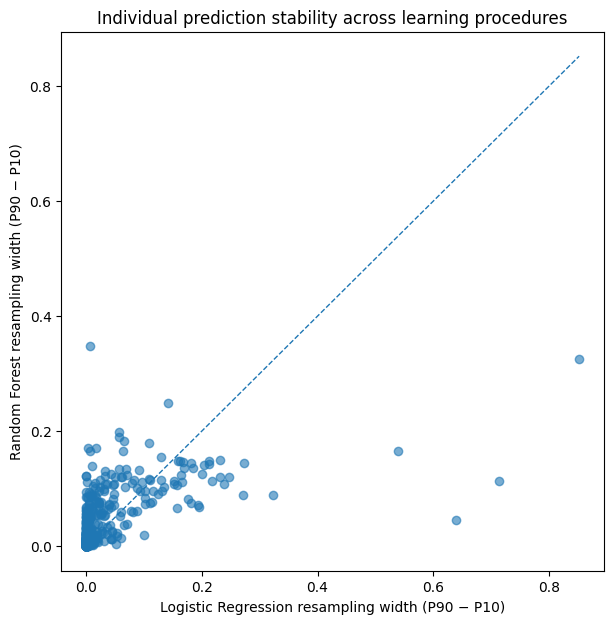

In [71]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    individual_comparison[
        "lr_resampling_width"
    ],
    individual_comparison[
        "rf_resampling_width"
    ],
    alpha=0.6
)

limit = max(
    individual_comparison[
        "lr_resampling_width"
    ].max(),
    individual_comparison[
        "rf_resampling_width"
    ].max()
)

ax.plot(
    [0, limit],
    [0, limit],
    linestyle="--",
    linewidth=1
)

ax.set_xlabel(
    "Logistic Regression resampling width (P90 − P10)"
)

ax.set_ylabel(
    "Random Forest resampling width (P90 − P10)"
)

ax.set_title(
    "Individual prediction stability across learning procedures"
)

plt.show()

In [73]:
primary_summary = pd.DataFrame({
    "procedure": [
        "Logistic Regression",
        "Random Forest"
    ],
    "mean_auc": [
        lr_auc["auc"].mean(),
        rf_auc["auc"].mean(),
    ],
    "sd_auc": [
        lr_auc["auc"].std(),
        rf_auc["auc"].std(),
    ],
    "mean_brier": [
        lr_brier["brier"].mean(),
        rf_brier["brier"].mean(),
    ],
    "sd_brier": [
        lr_brier["brier"].std(),
        rf_brier["brier"].std(),
    ],
    "median_W": [
        lr_individual["resampling_width"].median(),
        rf_individual["resampling_width"].median(),
    ],
    "P90_W": [
        np.quantile(lr_individual["resampling_width"], 0.90, method="linear"),
        np.quantile(rf_individual["resampling_width"], 0.90, method="linear"),
    ],
    "P95_W": [
        np.quantile(lr_individual["resampling_width"], 0.95, method="linear"),
        np.quantile(rf_individual["resampling_width"], 0.95, method="linear"),
    ],
    "max_W": [
        lr_individual["resampling_width"].max(),
        rf_individual["resampling_width"].max(),
    ],
})

In [74]:
print(primary_summary.to_string(index=False))

          procedure  mean_auc   sd_auc  mean_brier  sd_brier  median_W    P90_W    P95_W    max_W
Logistic Regression  0.994556 0.001299    0.020547  0.001677  0.001004 0.072620 0.157334 0.851826
      Random Forest  0.990640 0.000924    0.031696  0.001008  0.010450 0.107858 0.128518 0.347762


## Stage 5H: Cross-procedure divergence in individual prediction stability

Although Logistic Regression and Random Forest show substantial concordance
in observation-level resampling sensitivity, their instability magnitudes are
not identical.

This stage examines where the two procedures disagree most strongly.

The analysis is descriptive. Extreme observations are inspected to understand
the structure of cross-procedure disagreement, not to define new instability
subgroups or thresholds.

In [75]:
### Direction of observation-level stability differences

n_rf_higher = (
    individual_comparison["width_difference_rf_minus_lr"] > 0
).sum()

n_lr_higher = (
    individual_comparison["width_difference_rf_minus_lr"] < 0
).sum()

n_equal = (
    individual_comparison["width_difference_rf_minus_lr"] == 0
).sum()

direction_summary = pd.DataFrame({
    "direction": [
        "RF width > LR width",
        "LR width > RF width",
        "Equal width"
    ],
    "n": [
        n_rf_higher,
        n_lr_higher,
        n_equal
    ]
})

direction_summary["proportion"] = (
    direction_summary["n"]
    / len(individual_comparison)
)

print("--- DIRECTION OF RESAMPLING WIDTH DIFFERENCES (RF - LR) ---")
print(direction_summary.to_string(index=False))

--- DIRECTION OF RESAMPLING WIDTH DIFFERENCES (RF - LR) ---
          direction   n  proportion
RF width > LR width 463    0.813708
LR width > RF width 106    0.186292
        Equal width   0    0.000000


In [76]:
### Observations with the largest cross-procedure disagreements

rf_more_sensitive = (
    individual_comparison
    .sort_values(
        "width_difference_rf_minus_lr",
        ascending=False
    )
    .head(10)
    [
        [
            "observation_id",
            "y_true",
            "lr_median_probability",
            "rf_median_probability",
            "lr_resampling_width",
            "rf_resampling_width",
            "width_difference_rf_minus_lr",
        ]
    ]
)

lr_more_sensitive = (
    individual_comparison
    .sort_values(
        "width_difference_rf_minus_lr",
        ascending=True
    )
    .head(10)
    [
        [
            "observation_id",
            "y_true",
            "lr_median_probability",
            "rf_median_probability",
            "lr_resampling_width",
            "rf_resampling_width",
            "width_difference_rf_minus_lr",
        ]
    ]
)

print("--- TOP 10 OBSERVATIONS WHERE RANDOM FOREST IS MORE SENSITIVE ---")
print(rf_more_sensitive.to_string(index=False))

print("\n--- TOP 10 OBSERVATIONS WHERE LOGISTIC REGRESSION IS MORE SENSITIVE ---")
print(lr_more_sensitive.to_string(index=False))

--- TOP 10 OBSERVATIONS WHERE RANDOM FOREST IS MORE SENSITIVE ---
observation_id  y_true  lr_median_probability  rf_median_probability  lr_resampling_width  rf_resampling_width  width_difference_rf_minus_lr
      WDBC_191       0               0.004607               0.345000             0.007364             0.347762                      0.340398
      WDBC_424       0               0.002890               0.176375             0.003618             0.171462                      0.167845
      WDBC_379       1               0.994307               0.640125             0.007467             0.165438                      0.157971
      WDBC_209       0               0.021601               0.319250             0.017843             0.171275                      0.153432
      WDBC_275       0               0.031997               0.252875             0.056720             0.198088                      0.141367
      WDBC_406       0               0.102639               0.552188             0.05792

In [77]:
### Upper-tail overlap of resampling-sensitive observations

n_top = int(
    np.ceil(
        0.10 * len(individual_comparison)
    )
)

lr_top10_ids = set(
    individual_comparison
    .nlargest(
        n_top,
        "lr_resampling_width"
    )
    ["observation_id"]
)

rf_top10_ids = set(
    individual_comparison
    .nlargest(
        n_top,
        "rf_resampling_width"
    )
    ["observation_id"]
)

top10_overlap = (
    lr_top10_ids
    & rf_top10_ids
)

top10_union = (
    lr_top10_ids
    | rf_top10_ids
)

upper_tail_summary = pd.DataFrame({
    "quantity": [
        "Top-decile observations per procedure",
        "Shared top-decile observations",
        "Proportion of LR top decile also in RF top decile",
        "Jaccard overlap"
    ],
    "value": [
        n_top,
        len(top10_overlap),
        len(top10_overlap) / len(lr_top10_ids),
        len(top10_overlap) / len(top10_union),
    ]
})

print("--- UPPER-TAIL OVERLAP SUMMARY (TOP 10% RESAMPLING WIDTH) ---")
print(upper_tail_summary.to_string(index=False))

--- UPPER-TAIL OVERLAP SUMMARY (TOP 10% RESAMPLING WIDTH) ---
                                         quantity     value
            Top-decile observations per procedure 57.000000
                   Shared top-decile observations 32.000000
Proportion of LR top decile also in RF top decile  0.561404
                                  Jaccard overlap  0.390244
